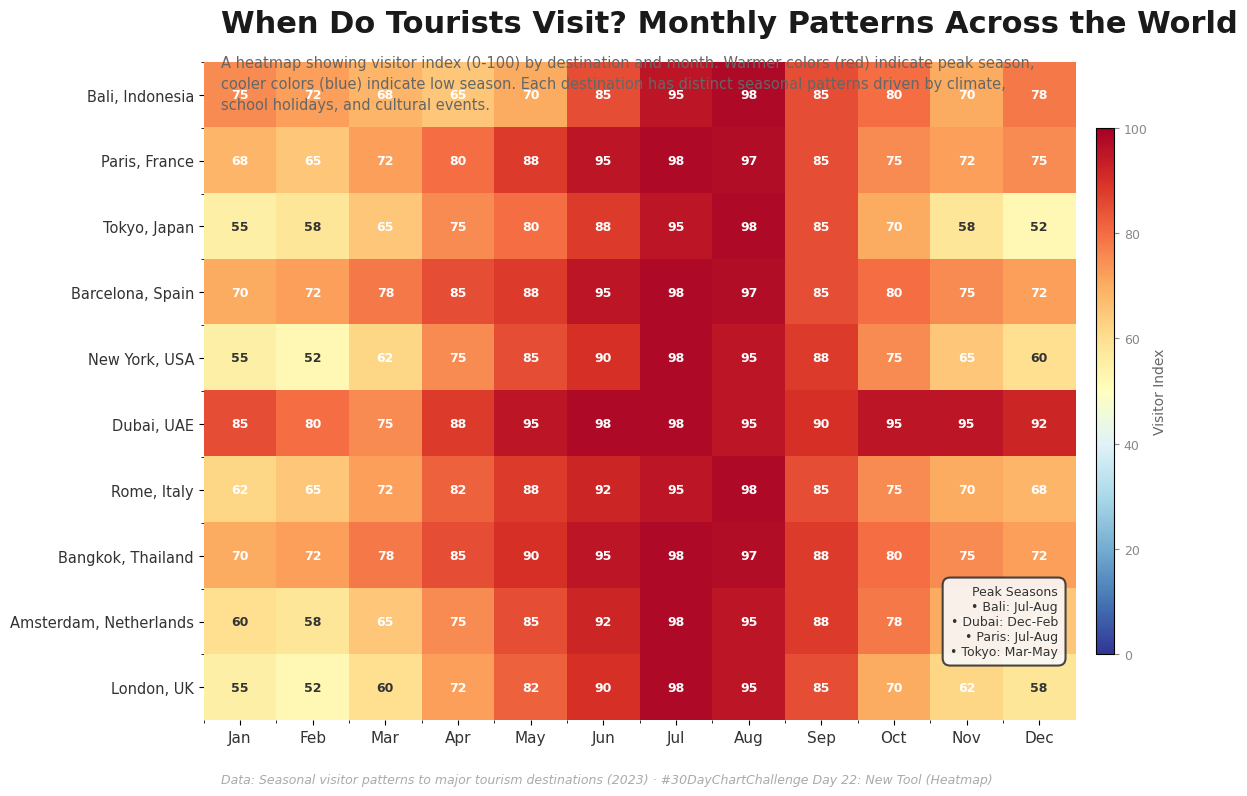

In [1]:
"""
#30DayChartChallenge — Day 22: New Tool
"When Do Tourists Visit? Monthly Patterns Across the World" — heatmap/matrix visualization
in the style of FlowingData: minimal chrome, direct labels, clean typography.

Data: Seasonal visitor patterns to major tourism destinations (normalized by month)
Using: Heatmap (new visualization tool for this challenge)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ---------------------------------------------------------------------------
# 1. SAMPLE DATA — Monthly visitor index by destination (0-100 scale)
# ---------------------------------------------------------------------------
destinations = [
    "Bali, Indonesia",
    "Paris, France",
    "Tokyo, Japan",
    "Barcelona, Spain",
    "New York, USA",
    "Dubai, UAE",
    "Rome, Italy",
    "Bangkok, Thailand",
    "Amsterdam, Netherlands",
    "London, UK"
]

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Visitor index (higher = peak season)
visitor_data = np.array([
    [75, 72, 68, 65, 70, 85, 95, 98, 85, 80, 70, 78],  # Bali (dry season peak)
    [68, 65, 72, 80, 88, 95, 98, 97, 85, 75, 72, 75],  # Paris (summer/spring)
    [55, 58, 65, 75, 80, 88, 95, 98, 85, 70, 58, 52],  # Tokyo (spring/autumn)
    [70, 72, 78, 85, 88, 95, 98, 97, 85, 80, 75, 72],  # Barcelona (summer)
    [55, 52, 62, 75, 85, 90, 98, 95, 88, 75, 65, 60],  # New York (summer/fall)
    [85, 80, 75, 88, 95, 98, 98, 95, 90, 95, 95, 92],  # Dubai (winter peak)
    [62, 65, 72, 82, 88, 92, 95, 98, 85, 75, 70, 68],  # Rome (spring/summer)
    [70, 72, 78, 85, 90, 95, 98, 97, 88, 80, 75, 72],  # Bangkok (cool/dry)
    [60, 58, 65, 75, 85, 92, 98, 95, 88, 78, 70, 65],  # Amsterdam (summer)
    [55, 52, 60, 72, 82, 90, 98, 95, 85, 70, 62, 58]   # London (summer)
])

df = pd.DataFrame(visitor_data, index=destinations, columns=months)

# ---------------------------------------------------------------------------
# 2. PLOT — Heatmap with direct labels
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(13, 8), facecolor="#FFFFFF")
ax.set_facecolor("#FFFFFF")

# Create heatmap
im = ax.imshow(df.values, cmap="RdYlBu_r", aspect="auto", vmin=0, vmax=100, zorder=2)

# Set ticks and labels
ax.set_xticks(np.arange(len(months)))
ax.set_yticks(np.arange(len(destinations)))
ax.set_xticklabels(months, fontsize=11, fontweight="500", color="#333333")
ax.set_yticklabels(destinations, fontsize=10.5, fontweight="500", color="#333333")

# Add value labels in each cell
for i in range(len(destinations)):
    for j in range(len(months)):
        value = df.values[i, j]
        text_color = "white" if value > 60 else "#333333"
        ax.text(j, i, f"{int(value)}", ha="center", va="center",
                color=text_color, fontsize=9, fontweight="600", zorder=3)

# Remove spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_visible(False)

# Grid
ax.set_xticks(np.arange(len(months)) - 0.5, minor=True)
ax.set_yticks(np.arange(len(destinations)) - 0.5, minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=2, zorder=1)

# Title & subtitle
ax.text(0.02, 1.08, "When Do Tourists Visit? Monthly Patterns Across the World",
        fontsize=22, fontweight="bold", color="#1a1a1a", transform=ax.transAxes, va="top")

ax.text(0.02, 1.01,
        "A heatmap showing visitor index (0-100) by destination and month. Warmer colors (red) indicate peak season,\n"
        "cooler colors (blue) indicate low season. Each destination has distinct seasonal patterns driven by climate,\n"
        "school holidays, and cultural events.",
        fontsize=10.5, color="#666666", transform=ax.transAxes, va="top", linespacing=1.5)

# Colorbar legend
cbar = plt.colorbar(im, ax=ax, orientation="vertical", pad=0.02, shrink=0.8, aspect=30)
cbar.set_label("Visitor Index", fontsize=10, color="#666666", fontweight="500")
cbar.ax.tick_params(colors="#888888", labelsize=9)

# Key insights box
ax.text(0.98, 0.15, "Peak Seasons\n• Bali: Jul-Aug\n• Dubai: Dec-Feb\n• Paris: Jul-Aug\n• Tokyo: Mar-May",
        fontsize=9, color="#333333", transform=ax.transAxes, ha="right", va="center",
        bbox=dict(boxstyle="round,pad=0.6", facecolor="#f9f9f9", edgecolor="#333333", linewidth=1.5, alpha=0.9))

# Source
ax.text(0.02, -0.08,
        "Data: Seasonal visitor patterns to major tourism destinations (2023) · #30DayChartChallenge Day 22: New Tool (Heatmap)",
        fontsize=9, color="#aaaaaa", style="italic", transform=ax.transAxes, va="top")

plt.tight_layout()
plt.savefig("day22_new_tool.png", dpi=200, facecolor="#FFFFFF", bbox_inches="tight")
plt.show()